2025-05-14 15:18:27.698620: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Carregando modelo de best_model_bce_dice_v3.keras...


2025-05-14 15:18:30.555588: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-14 15:18:34.036925: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-14 15:18:34.037015: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-14 15:18:34.038398: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-14 15:18:34.038510: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

Carregando conjunto de dados de teste...

Avaliando modelo no conjunto de teste com métricas padrão...


I0000 00:00:1747235998.571262     130 service.cc:146] XLA service 0x7c5b8001c6d0 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747235998.571308     130 service.cc:154]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-05-14 15:19:58.736255: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747236078.666400     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 201s 626ms/step - accuracy: 0.7428 - loss: 0.4902 - multiclass_iou: 0.0889 - precision: 0.7433 - recall: 0.6028

===== Métricas Gerais do TensorFlow =====
Loss: 0.5021
Accuracy: 0.6963
Mean IoU: 0.0725
Precision: 0.6957
Recall: 0.5505

Processando métricas multilabel incrementalmente...
Processando batch 1...
Processando batch 2...
Processando batch 3...
Processando batch 4...
Processando batch 5...
Processando batch 6...
Processando batch 7...
Processando batch 8...
Processando batch 9...
Processando batch 10...
Processando batch 11...
Processando batch 12...
Processando batch 13...
Processando batch 14...
Processando batch 15...
Processando batch 16...
Processando batch 17...
Processando batch 18...
Processando batch 19...
Processando batch 20...
Processando batch 21...
Processando batch 22...
Processando batch 23...
Processando batch 24...
Processando batch 25...
Processando batch 26...
Processando batch 27...
Processando batch 28...
Processando batch 29..

2025-05-14 15:25:16.290010: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



===== Métricas Binárias por Classe =====
   class   prevalence      iou  precision   recall  specificity  f1_score  balanced_acc
 Class_1 7.445323e-01 0.554095   0.818899 0.632184     0.594620  0.710336      0.613402
 Class_2 3.295690e-04 0.000000   0.000000 0.000000     1.000000  0.000000      0.500000
 Class_3 0.000000e+00 0.000000   0.000000 0.000000     1.000000  0.000000      0.500000
 Class_4 1.954436e-04 0.000000   0.000000 0.000000     1.000000  0.000000      0.500000
 Class_5 3.446043e-04 0.000000   0.000000 0.000000     0.999999  0.000000      0.499999
 Class_6 0.000000e+00 0.000000   0.000000 0.000000     1.000000  0.000000      0.500000
 Class_7 4.913658e-05 0.000000   0.000000 0.000000     1.000000  0.000000      0.500000
 Class_8 4.656613e-06 0.000000   0.000000 0.000000     1.000000  0.000000      0.500000
 Class_9 9.001188e-03 0.000000   0.000000 0.000000     0.999956  0.000000      0.499978
Class_10 6.038918e-02 0.506943   0.509812 0.983389     0.948788  0.662293     

<Figure size 2000x900 with 0 Axes>

<Figure size 2000x1600 with 0 Axes>

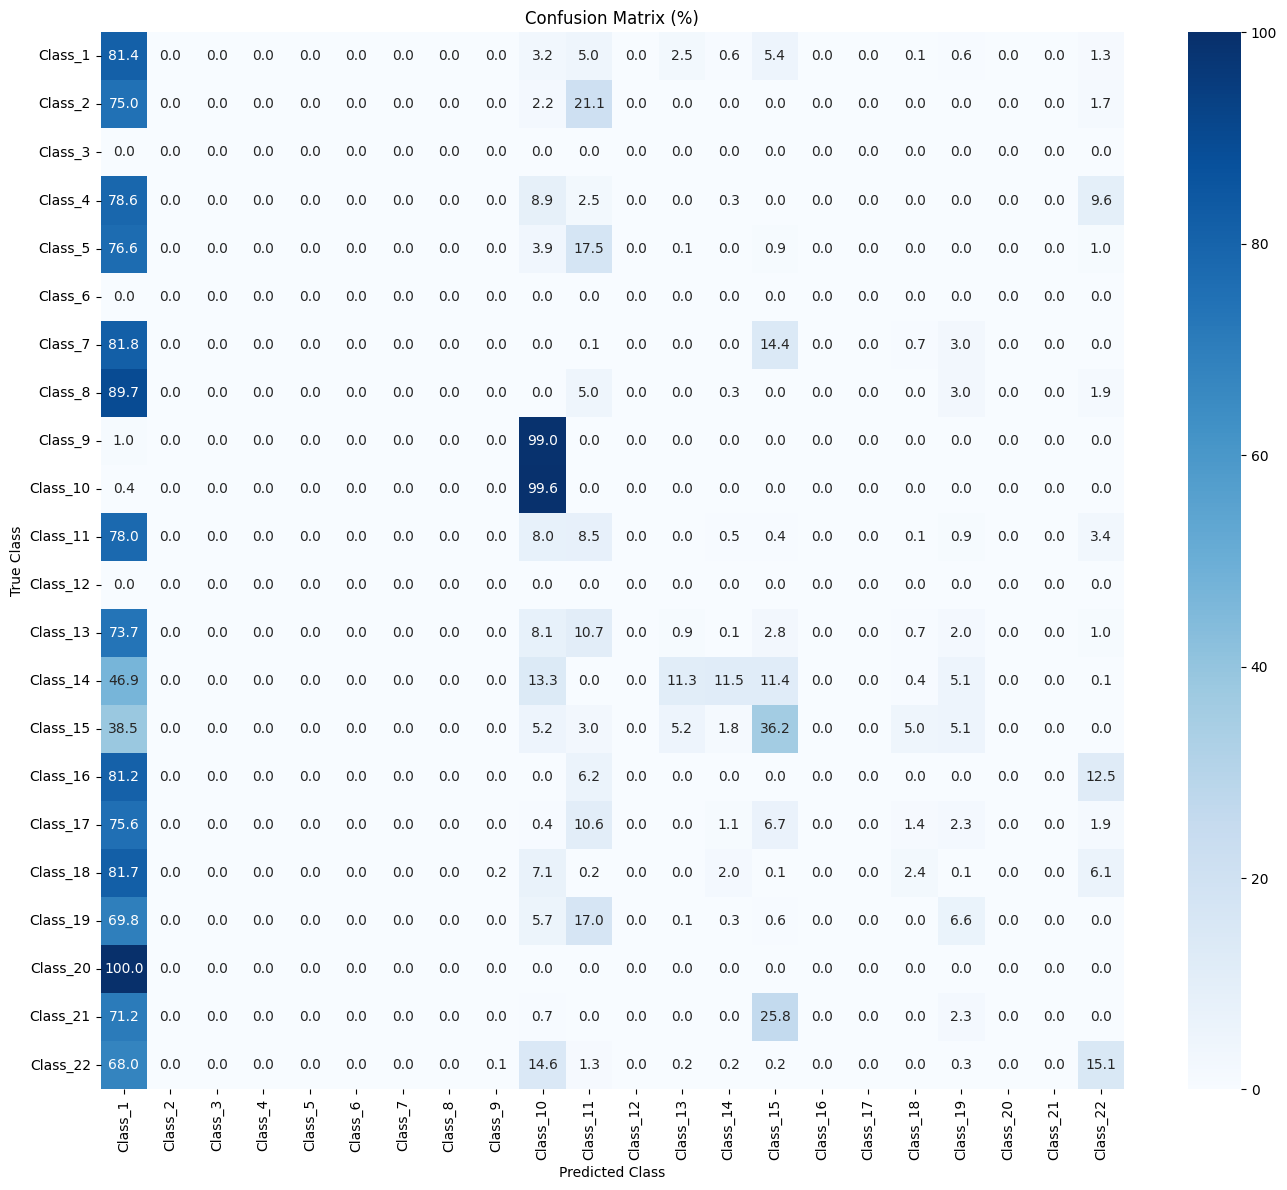


Calculando matrizes de confusão binárias por classe...

Calculando correlação entre previsões de classes...

Gerando visualizações das métricas por classe...


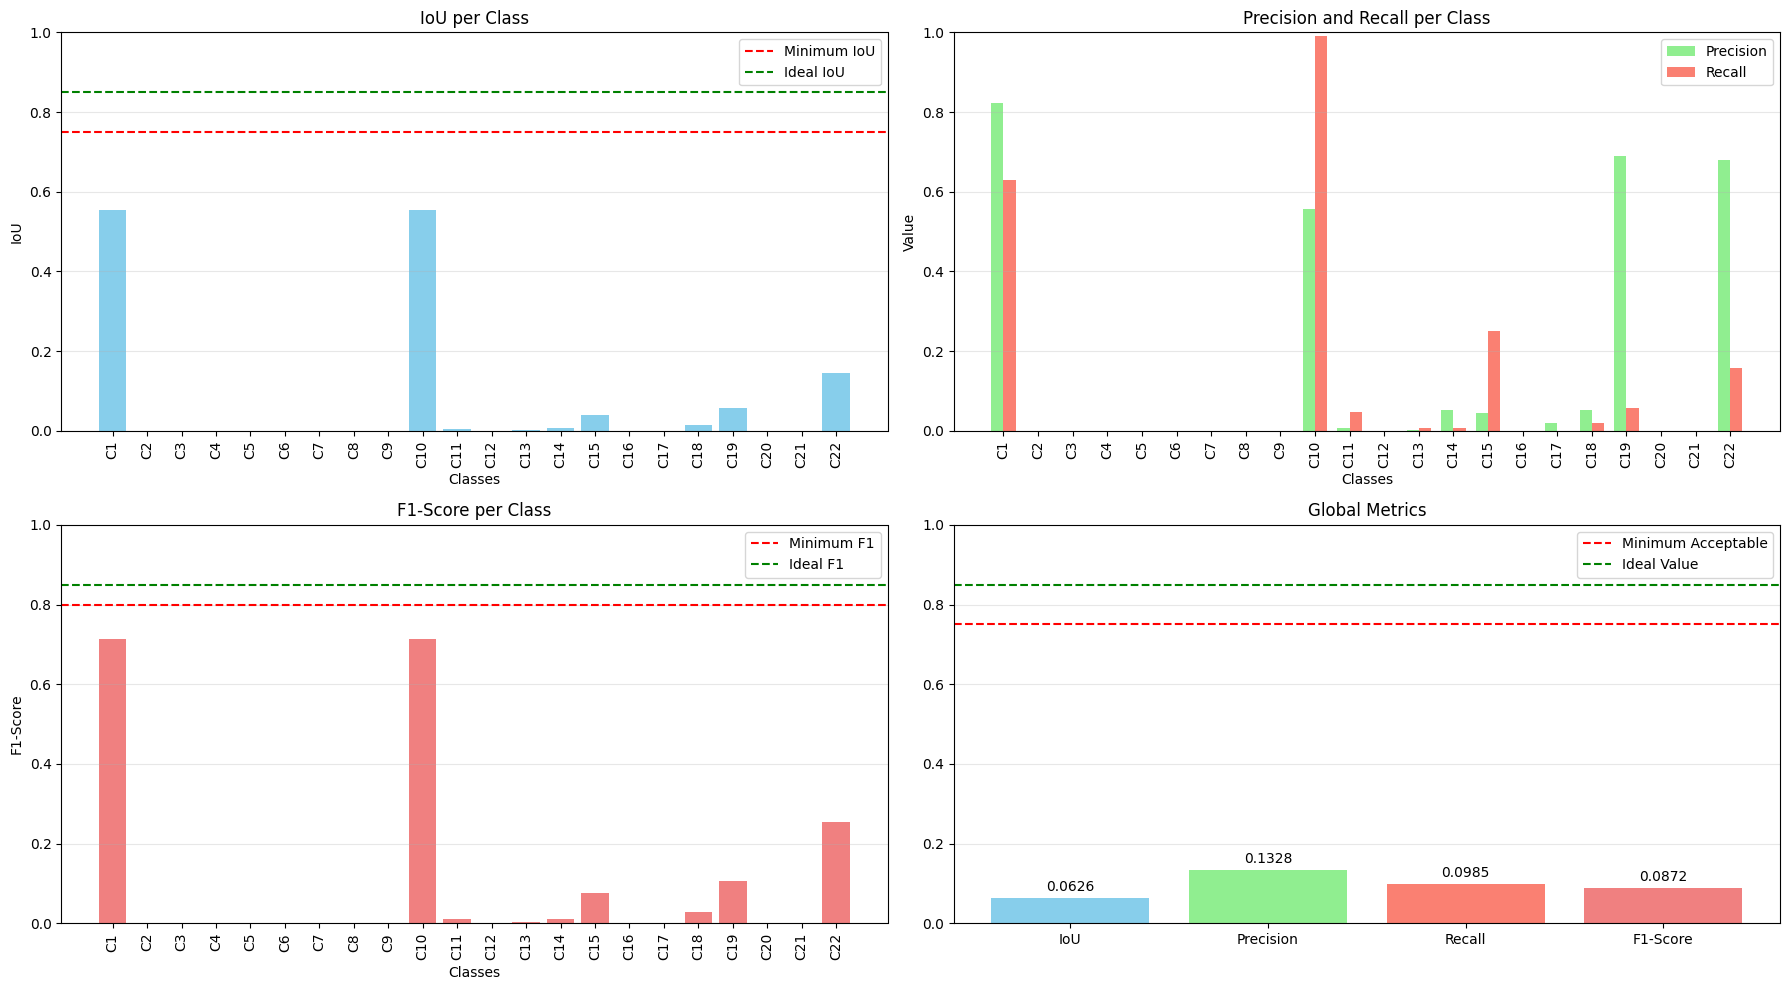


Gerando imagens individuais para cada métrica...
Imagens individuais geradas no diretório 'results_unet_multilabel':
 - iou_per_class.png
 - precision_recall_per_class.png
 - f1_per_class.png
 - global_metrics.png

Todos os resultados foram salvos no diretório 'results_unet_multilabel'


In [1]:
import tensorflow as tf#type: ignore
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pathlib
import os
from dotenv import load_dotenv
from sklearn.metrics import confusion_matrix

### Redefinir as funções necessárias para carregar o modelo treinado ###
# Perda
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def multilabel_dice_loss(y_true, y_pred):
    loss = 0
    for i in range(y_pred.shape[-1]):
        loss += dice_loss(y_true[..., i], y_pred[..., i])
    return loss / y_pred.shape[-1]

def bce_dice_loss(y_true, y_pred, dice_weight=0.5):
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_true, y_pred)
    dice = multilabel_dice_loss(y_true, y_pred)
    return (1 - dice_weight) * bce + dice_weight * dice

def loss_function(y_true, y_pred):
    return bce_dice_loss(y_true, y_pred, dice_weight=0.5)


# Métricas
class MultilabelIoU(tf.keras.metrics.Metric):
    def __init__(self, num_classes=22, threshold=0.5, name='multiclass_iou', **kwargs):
        super(MultilabelIoU, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.threshold = threshold
        # Manter somas separadas para cada classe
        self.total_intersection = self.add_weight(
            name='total_intersection', 
            shape=(num_classes,),
            initializer='zeros')
        self.total_union = self.add_weight(
            name='total_union', 
            shape=(num_classes,),
            initializer='zeros')
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Binarizar previsões
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        
        # Calcular intersecção e união para todas as classes
        intersection = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2])
        union = tf.reduce_sum(y_true, axis=[0, 1, 2]) + tf.reduce_sum(y_pred, axis=[0, 1, 2]) - intersection
        
        # Acumular estatísticas por classe
        self.total_intersection.assign_add(intersection)
        self.total_union.assign_add(union)
        
    def result(self):
        # Calcular IoU para cada classe (evitando divisão por zero)
        iou = tf.where(
            self.total_union > 0, 
            self.total_intersection / (self.total_union + 1e-10),
            tf.zeros_like(self.total_union)  # Usar 0 para classes ausentes (não 1!)
        )
        
        # Calcular média apenas para classes que aparecem nos dados
        valid_classes = tf.cast(self.total_union > 0, tf.float32)
        num_valid_classes = tf.reduce_sum(valid_classes)
        
        mean_iou = tf.cond(
            num_valid_classes > 0,
            lambda: tf.reduce_sum(iou) / num_valid_classes,
            lambda: tf.constant(0.0)
        )
        
        return mean_iou
    
    def reset_state(self):
        self.total_intersection.assign(tf.zeros_like(self.total_intersection))
        self.total_union.assign(tf.zeros_like(self.total_union))


# Conjunto de Dados
def load_test_dataset():
    """
    Carrega o conjunto de dados de teste
    """
    # Carregar variáveis de ambiente
    load_dotenv()
    
    img_dir_str = os.getenv("BASE_IMG_FOLDER")
    if img_dir_str is None:
        raise ValueError("A variável de ambiente BASE_IMG_FOLDER não está definida no arquivo .env")
    img_dir = pathlib.Path(img_dir_str)
    
    mask_dir_str = os.getenv("NUMPY_FOLDER")
    if mask_dir_str is None:
        raise ValueError("A variável de ambiente NUMPY_FOLDER não está definida no arquivo .env")
    mask_dir = pathlib.Path(mask_dir_str)
    
    # Funções para extrair número do arquivo
    def get_file_number(filepath):
        return int(os.path.basename(filepath).replace('.png', ''))
    
    def get_file_number_mask(filepath):
        return int(os.path.basename(filepath).replace('.npy', ''))
    
    # Listar arquivos
    mask_files = [str(path) for path in mask_dir.glob('*.npy') if os.path.exists(path)]
    image_files = [str(path) for path in img_dir.glob('*.png') if os.path.exists(path)]
    
    # Ordenar
    image_files = sorted(image_files, key=get_file_number)
    mask_files = sorted(mask_files, key=get_file_number_mask)
    
    def load_and_preprocess_image_mask(image_path, mask_path):
        try:
            # Carregar imagem
            img = tf.io.read_file(image_path)
            img = tf.image.decode_png(img, channels=3)
            img = tf.image.resize(img, [512, 512])
            img = tf.cast(img, tf.float32) / 255.0
            
            # Carregar máscara
            mask = np.load(mask_path.numpy().decode())
            mask = tf.convert_to_tensor(mask, dtype=tf.float32)
            mask = mask / 255.0
            mask = tf.where(mask >= 0.3, 1.0, 0.0)
            
            return img, mask
        except Exception as e:
            print(f"Erro ao processar {image_path}, {mask_path}: {str(e)}")
            raise
    
    def process_path(image_path, mask_path):
        img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
        img.set_shape((512, 512, 3))
        mask.set_shape((512, 512, 22))
        return img, mask
    
    # Criar dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Dividir dataset (mesma lógica do código original)
    dataset_size = tf.data.experimental.cardinality(dataset).numpy()
    train_size = int(0.8 * dataset_size)
    val_size = int(0.1 * dataset_size)
    
    # Dividir usando a mesma metodologia do treinamento
    shuffled_dataset = dataset.shuffle(buffer_size=32)
    train_dataset = shuffled_dataset.take(train_size)
    remaining_dataset = shuffled_dataset.skip(train_size)
    val_dataset = remaining_dataset.take(val_size)
    test_dataset = remaining_dataset.skip(val_size)
    
    # Configurar batch
    test_dataset = test_dataset.batch(8).prefetch(1)
    
    return test_dataset


# Funções de avaliação
def process_batch_metrics(y_true_batch, y_pred_batch, threshold=0.5, num_classes=22):
    """
    Processa métricas para um único batch
    Retorna IoU, Precision, Recall, F1 e contribuição para a matriz de confusão
    """
    
    # Para métricas por canal (TP, FP, FN, TN), pode usar o threshold
    y_pred_binary = tf.cast(y_pred_batch > threshold, tf.float32)
    
    # Arrays para armazenar resultados deste batch
    batch_tp = np.zeros(num_classes)
    batch_fp = np.zeros(num_classes)
    batch_fn = np.zeros(num_classes)
    batch_tn = np.zeros(num_classes)
    
    # Calcular métricas para cada classe
    for i in range(num_classes):
        y_true_class = y_true_batch[..., i]
        y_pred_class = y_pred_binary[..., i]
        
        # True Positives, False Positives, False Negatives, True Negatives
        tp = tf.reduce_sum(y_true_class * y_pred_class).numpy()
        fp = tf.reduce_sum((1 - y_true_class) * y_pred_class).numpy()
        fn = tf.reduce_sum(y_true_class * (1 - y_pred_class)).numpy()
        tn = tf.reduce_sum((1 - y_true_class) * (1 - y_pred_class)).numpy()
        
        batch_tp[i] = tp
        batch_fp[i] = fp
        batch_fn[i] = fn
        batch_tn[i] = tn

    # Para a matriz de confusão, é melhor usar as probabilidades originais sem threshold
    y_true_argmax = tf.argmax(y_true_batch, axis=-1).numpy().flatten()
    y_pred_argmax = tf.argmax(y_pred_batch, axis=-1).numpy().flatten()
    
    # Computar a matriz de confusão para este batch
    batch_cm = confusion_matrix(y_true_argmax, y_pred_argmax, labels=range(num_classes))
    
    return batch_tp, batch_fp, batch_fn, batch_tn, batch_cm

def calculate_final_metrics(total_tp, total_fp, total_fn, total_tn, num_classes):
    """
    Calcula métricas finais a partir dos totais acumulados
    """
    iou_per_class = np.zeros(num_classes)
    precision_per_class = np.zeros(num_classes)
    recall_per_class = np.zeros(num_classes)
    f1_per_class = np.zeros(num_classes)
    
    for i in range(num_classes):
        # IoU = TP / (TP + FP + FN)
        iou_per_class[i] = total_tp[i] / (total_tp[i] + total_fp[i] + total_fn[i] + 1e-10)
        
        # Precision = TP / (TP + FP)
        precision_per_class[i] = total_tp[i] / (total_tp[i] + total_fp[i] + 1e-10)
        
        # Recall = TP / (TP + FN)
        recall_per_class[i] = total_tp[i] / (total_tp[i] + total_fn[i] + 1e-10)
        
        # F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
        f1_per_class[i] = 2 * precision_per_class[i] * recall_per_class[i] / (precision_per_class[i] + recall_per_class[i] + 1e-10)
    
    return iou_per_class, precision_per_class, recall_per_class, f1_per_class

def plot_confusion_matrix(cm, class_names=None, figsize=(14, 12), cmap='Blues', save_path=None):
    """
    Plota a matriz de confusão
    """
    if class_names is None:
        class_names = [f'Class {i+1}' for i in range(cm.shape[0])]
    
    plt.figure(figsize=figsize)
    
    # Normalizar para porcentagens por linha (classe verdadeira)
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
    
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.title('Confusion Matrix (%)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


### Novas funções para avaliação multilabel ###
def evaluate_binary_metrics_per_class(y_true_batch, y_pred_batch, threshold=0.5, num_classes=22):
    """
    Calcula métricas binárias para cada classe separadamente
    """
    # Arrays para armazenar resultados
    precision_list = []
    recall_list = []
    specificity_list = []
    f1_list = []
    iou_list = []
    balanced_acc_list = []
    prevalence_list = []
    
    # Transformar para numpy para cálculos
    y_true_np = y_true_batch.numpy() if isinstance(y_true_batch, tf.Tensor) else y_true_batch
    y_pred_np = y_pred_batch.numpy() if isinstance(y_pred_batch, tf.Tensor) else y_pred_batch
    
    # Aplicar threshold
    y_pred_binary = (y_pred_np > threshold).astype(np.float32)
    y_true_binary = (y_true_np > 0.5).astype(np.float32)
    
    # Calcular métricas para cada classe
    for i in range(num_classes):
        # Extrair canal para a classe atual
        y_true_class = y_true_binary[..., i].flatten()
        y_pred_class = y_pred_binary[..., i].flatten()
        
        # Calcular confusion matrix para esta classe
        tp = np.sum(y_true_class * y_pred_class)
        fp = np.sum((1 - y_true_class) * y_pred_class)
        fn = np.sum(y_true_class * (1 - y_pred_class))
        tn = np.sum((1 - y_true_class) * (1 - y_pred_class))
        
        # Total de pixels
        total = tp + fp + fn + tn
        
        # Evitar divisão por zero
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        balanced_acc = (recall + specificity) / 2
        prevalence = (tp + fn) / total
        
        # Armazenar resultados
        precision_list.append(precision)
        recall_list.append(recall)
        specificity_list.append(specificity)
        f1_list.append(f1)
        iou_list.append(iou)
        balanced_acc_list.append(balanced_acc)
        prevalence_list.append(prevalence)
    
    # Criar DataFrame com resultados em inglês
    class_names = [f'Class_{i+1}' for i in range(num_classes)]
    results_df = pd.DataFrame({
        'class': class_names,
        'prevalence': prevalence_list,
        'iou': iou_list,
        'precision': precision_list,
        'recall': recall_list,
        'specificity': specificity_list,
        'f1_score': f1_list,
        'balanced_acc': balanced_acc_list
    })
    
    return results_df

def calculate_multilabel_metrics(y_true, y_pred, threshold=0.5):
    """
    Calcula métricas específicas para problemas multilabel
    """
    # Transformar para numpy para cálculos
    y_true_np = y_true.numpy() if isinstance(y_true, tf.Tensor) else y_true
    y_pred_np = y_pred.numpy() if isinstance(y_pred, tf.Tensor) else y_pred
    
    # Binarizar previsões
    y_true_binary = (y_true_np > 0.5).astype(np.float32)
    y_pred_binary = (y_pred_np > threshold).astype(np.float32)
    
    # Reshape para formato (n_amostras, n_classes)
    batch_size = y_true_np.shape[0]
    n_pixels_per_image = y_true_np.shape[1] * y_true_np.shape[2]
    n_classes = y_true_np.shape[3]
    
    y_true_flat = y_true_binary.reshape(batch_size * n_pixels_per_image, n_classes)
    y_pred_flat = y_pred_binary.reshape(batch_size * n_pixels_per_image, n_classes)
    y_pred_scores = y_pred_np.reshape(batch_size * n_pixels_per_image, n_classes)
    
    # 1. Hamming Loss - fração de labels incorretamente previstos
    hamming_loss = np.mean(y_true_flat != y_pred_flat)
    
    # 2. Exact Match Ratio - proporção de amostras onde todas as classes foram classificadas corretamente
    exact_match = np.all(y_true_flat == y_pred_flat, axis=1)
    exact_match_ratio = np.mean(exact_match)
    
    # 3. Subset Accuracy - igual ao Exact Match Ratio
    subset_accuracy = exact_match_ratio
    
    # 4. Zeroshot Distribution - quantos pixels não têm nenhuma classe prevista
    zero_preds = np.sum(y_pred_flat, axis=1) == 0
    zero_pred_ratio = np.mean(zero_preds)
    
    # 5. Multi-label Distribution - estatísticas sobre número de classes por pixel
    true_class_counts = np.sum(y_true_flat, axis=1)
    pred_class_counts = np.sum(y_pred_flat, axis=1)
    
    mean_true_classes = np.mean(true_class_counts)
    mean_pred_classes = np.mean(pred_class_counts)
    
    # 6. Jaccard Similarity por amostra (IoU por pixel considerando todas as classes)
    intersection = np.sum(np.logical_and(y_true_flat, y_pred_flat), axis=1)
    union = np.sum(np.logical_or(y_true_flat, y_pred_flat), axis=1)
    
    # Evitar divisão por zero
    valid_samples = union > 0
    sample_jaccard = np.zeros(len(union))
    sample_jaccard[valid_samples] = intersection[valid_samples] / union[valid_samples]
    mean_sample_jaccard = np.mean(sample_jaccard)
    
    results = {
        'hamming_loss': hamming_loss,
        'exact_match_ratio': exact_match_ratio,
        'subset_accuracy': subset_accuracy,
        'zero_pred_ratio': zero_pred_ratio,
        'mean_true_classes_per_pixel': mean_true_classes,
        'mean_pred_classes_per_pixel': mean_pred_classes,
        'mean_pixel_jaccard': mean_sample_jaccard
    }
    
    return results

def plot_multilabel_visualizations(y_true, y_pred, threshold=0.5, num_classes=22, save_dir='.'):
    """
    Cria visualizações específicas para segmentação multilabel
    """
    # Transformar para numpy para visualizações
    y_true_np = y_true.numpy() if isinstance(y_true, tf.Tensor) else y_true
    y_pred_np = y_pred.numpy() if isinstance(y_pred, tf.Tensor) else y_pred
    
    # Binarizar previsões
    y_true_binary = (y_true_np > 0.5).astype(np.float32)
    y_pred_binary = (y_pred_np > threshold).astype(np.float32)
    
    # Criar diretório para salvar as visualizações
    os.makedirs(save_dir, exist_ok=True)


    # 1. Distribuição de classes por pixel
    plt.figure(figsize=(12, 6))
    
    classes_per_pixel_true = np.sum(y_true_binary, axis=-1).flatten()
    classes_per_pixel_pred = np.sum(y_pred_binary, axis=-1).flatten()
    
    max_classes = max(np.max(classes_per_pixel_true), np.max(classes_per_pixel_pred))
    
    bins = np.arange(0, min(max_classes + 2, 10)) - 0.5
    plt.hist([classes_per_pixel_true, classes_per_pixel_pred], 
            bins=bins, 
            label=['Ground Truth', 'Prediction'], 
            alpha=0.7,
            density=True)
    
    plt.xticks(range(0, int(min(max_classes + 1, 9))))

    plt.xlabel('Number of Classes per Pixel')
    plt.ylabel('Density')
    plt.title('Distribution of Classes per Pixel')
    plt.legend(['Ground Truth', 'Prediction'])
    plt.grid(alpha=0.3)
    plt.savefig(f'{save_dir}/classes_per_pixel.png', dpi=300, bbox_inches='tight')
    plt.close()


    # 2. Co-ocorrência de classes
    plt.figure(figsize=(20, 9))
    
    # Reshape para formato (n_amostras, n_classes)
    batch_size = y_true_np.shape[0]
    n_pixels_per_image = y_true_np.shape[1] * y_true_np.shape[2]
    
    y_true_flat = y_true_binary.reshape(batch_size * n_pixels_per_image, num_classes)
    y_pred_flat = y_pred_binary.reshape(batch_size * n_pixels_per_image, num_classes)
    
    # Matriz de co-ocorrência de classes
    cooccurrence_true = np.zeros((num_classes, num_classes))
    cooccurrence_pred = np.zeros((num_classes, num_classes))
    
    for i in range(num_classes):
        for j in range(num_classes):
            cooccurrence_true[i, j] = np.sum(np.logical_and(y_true_flat[:, i], y_true_flat[:, j]))
            cooccurrence_pred[i, j] = np.sum(np.logical_and(y_pred_flat[:, i], y_pred_flat[:, j]))
    
    # Normalizar para porcentagem
    total_pixels = batch_size * n_pixels_per_image
    cooccurrence_true = cooccurrence_true / total_pixels * 100
    cooccurrence_pred = cooccurrence_pred / total_pixels * 100
    
    # Plottar a matriz de co-ocorrência
    plt.figure(figsize=(20, 16))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    class_labels = [f'C{i+1}' for i in range(num_classes)]

    # Log-scale para destacar valores pequenos
    cooccurrence_true_plot = np.log1p(cooccurrence_true)  # log(1+x) para lidar com zeros
    cooccurrence_pred_plot = np.log1p(cooccurrence_pred)

    # Ground Truth com anotações explícitas
    sns.heatmap(cooccurrence_true_plot, ax=ax1, cmap='YlGnBu', 
                xticklabels=class_labels, yticklabels=class_labels, annot=True, fmt='.2f')
    ax1.set_title('Class Co-occurrence - Ground Truth (log scale)')

    # Prediction com anotações explícitas
    sns.heatmap(cooccurrence_pred_plot, ax=ax2, cmap='YlGnBu',
                xticklabels=class_labels, yticklabels=class_labels, annot=True, fmt='.2f')
    ax2.set_title('Class Co-occurrence - Prediction (log scale)')

    plt.tight_layout()
    plt.savefig(f'{save_dir}/class_cooccurrence_log.png', dpi=300, bbox_inches='tight')
    plt.close()


    # 3. Visualizar a calibração do modelo - valores de confiança vs. precisão
    plt.figure(figsize=(12, 10))

    # Aumentar número de bins para melhor resolução
    confidence_bins = np.linspace(0, 1, 21)  # 20 bins em vez de 10
    bin_centers = (confidence_bins[1:] + confidence_bins[:-1]) / 2

    avg_precision_by_confidence = []
    bin_counts = []

    for i in range(len(confidence_bins) - 1):
        lower = confidence_bins[i]
        upper = confidence_bins[i+1]
        
        # Para cada classe
        class_precisions = []
        bin_count = 0  # Contador para este bin
        
        for cls in range(num_classes):
            # Selecionar previsões com confiança neste intervalo
            y_pred_cls = y_pred_np[..., cls].flatten()
            y_true_cls = y_true_binary[..., cls].flatten()
            
            mask = (y_pred_cls >= lower) & (y_pred_cls < upper)
            bin_count += np.sum(mask)  # Acumular contagem
            
            if np.sum(mask) > 0:
                precision = np.mean(y_true_cls[mask])
                class_precisions.append(precision)
        
        if class_precisions:
            avg_precision_by_confidence.append(np.mean(class_precisions))
            bin_counts.append(bin_count)
        else:
            avg_precision_by_confidence.append(0)
            bin_counts.append(0)

    # Aplicar transformação logarítmica para reduzir o desequilíbrio
    bin_counts = np.array(bin_counts)
    log_counts = np.log1p(bin_counts)  # log(1+x) para lidar com zeros

    # Definir tamanho mínimo e máximo para os pontos
    min_size = 50  # Tamanho mínimo para pontos com poucas amostras
    max_size = 300  # Tamanho máximo para o ponto com mais amostras

    # Normalizar contagens na escala logarítmica
    if log_counts.max() > 0:
        normalized_counts = min_size + (max_size - min_size) * (log_counts / log_counts.max())
    else:
        normalized_counts = np.ones_like(log_counts) * min_size

    # Criar scatter plot com tamanhos ajustados
    scatter = plt.scatter(bin_centers, avg_precision_by_confidence, s=normalized_counts, 
                        alpha=0.7, c=bin_centers, cmap='viridis', 
                        edgecolor='black', linewidth=1)

    # Linha diagonal de calibração perfeita
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Calibration')

    # Removido o bloco de anotações de coordenadas para deixar o gráfico mais limpo

    # Melhorar aparência do gráfico
    plt.xlabel('Average Confidence', fontsize=12)
    plt.ylabel('Actual Precision', fontsize=12)
    plt.title('Model Calibration (Confidence vs. Precision)', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10)

    # Adicionar colorbar para indicar confiança
    cbar = plt.colorbar(scatter)
    cbar.set_label('Confidence Level', fontsize=10)

    # Adicionar linha horizontal e vertical em 0.5 para referência
    plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)

    # Mudei a posição do texto explicativo para o canto inferior direito
    plt.figtext(0.75, 0.15, 
            "Larger circles = more samples\nPoints above line: model underconfident\nPoints below line: model overconfident", 
            fontsize=10, 
            ha='right',  # Alinhamento à direita para não ultrapassar a borda
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'{save_dir}/model_calibration.png', dpi=300, bbox_inches='tight')
    plt.close()
    

    return {
        'classes_per_pixel': {
            'mean_true': np.mean(classes_per_pixel_true),
            'mean_pred': np.mean(classes_per_pixel_pred),
            'max_true': np.max(classes_per_pixel_true),
            'max_pred': np.max(classes_per_pixel_pred)
        }
    }


def sort_classes_numerically(df, column_class='class'):
    """Ordena DataFrame por número da classe em vez de ordem alfabética"""
    if column_class in df.columns:
        df = df.copy()
        df['class_number'] = df[column_class].str.extract(r'_(\d+)').astype(int)
        df = df.sort_values('class_number').drop('class_number', axis=1)
    return df


# Função principal de avaliação multilabel
def evaluate_multilabel_segmentation(model, test_dataset, threshold=0.5, num_classes=22, save_dir='results_unet_multilabel'):
    """
    Avaliação abrangente para segmentação multilabel
    """
    # Criar diretório para salvar resultados
    os.makedirs(save_dir, exist_ok=True)
    
    # Para acumular resultados
    binary_metrics_dfs = []
    multilabel_metrics_list = []
    
    # Para métricas gerais do TensorFlow
    print("\nAvaliando modelo no conjunto de teste com métricas padrão...")
    test_loss, test_acc, test_iou, test_precision, test_recall = model.evaluate(test_dataset, verbose=1)
    
    print("\n===== Métricas Gerais do TensorFlow =====")
    print(f"Loss: {test_loss:.4f}")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Mean IoU: {test_iou:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    
    # Para a matriz de confusão tradicional
    total_cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    
    # Para as métricas TP, FP, FN, TN acumuladas (mantidas do código original)
    total_tp = np.zeros(num_classes)
    total_fp = np.zeros(num_classes)
    total_fn = np.zeros(num_classes)
    total_tn = np.zeros(num_classes)
    
    # Para visualização de exemplo
    example_batch_saved = False
    
    # Processar batch por batch
    print("\nProcessando métricas multilabel incrementalmente...")
    batch_count = 0
    
    for images, masks in test_dataset:
        batch_count += 1
        print(f"Processando batch {batch_count}...")
        
        # Fazer previsões
        predictions = model.predict(images, verbose=0)
        
        # 1. Métricas do código original
        batch_tp, batch_fp, batch_fn, batch_tn, batch_cm = process_batch_metrics(
            masks, predictions, threshold=threshold, num_classes=num_classes
        )
        
        # Acumular métricas originais
        total_tp += batch_tp
        total_fp += batch_fp
        total_fn += batch_fn
        total_tn += batch_tn
        total_cm += batch_cm
        
        # 2. Métricas binárias por classe
        binary_df = evaluate_binary_metrics_per_class(
            masks, predictions, threshold=threshold, num_classes=num_classes
        )
        binary_metrics_dfs.append(binary_df)
        
        # 3. Métricas multilabel
        ml_metrics = calculate_multilabel_metrics(
            masks, predictions, threshold=threshold
        )
        multilabel_metrics_list.append(ml_metrics)
        
        # 4. Gerar visualizações para um batch de exemplo
        if not example_batch_saved:
            plot_multilabel_visualizations(
                masks, predictions, threshold=threshold, 
                num_classes=num_classes, save_dir=save_dir
            )
            example_batch_saved = True
    
    # Consolidar resultados
    # 1. Métricas binárias
    all_binary_metrics = pd.concat(binary_metrics_dfs)
    binary_metrics_summary = all_binary_metrics.groupby('class').mean().reset_index()
    # Aplicando aos ordenação aos resultados
    binary_metrics_summary = sort_classes_numerically(binary_metrics_summary)
    
    # 2. Métricas multilabel
    multilabel_results = {}
    for key in multilabel_metrics_list[0].keys():
        multilabel_results[key] = np.mean([d[key] for d in multilabel_metrics_list])
    
    # 3. Métricas originais
    iou_per_class, precision_per_class, recall_per_class, f1_per_class = calculate_final_metrics(
        total_tp, total_fp, total_fn, total_tn, num_classes
    )
    
    # Exibir resultados
    print("\n===== Métricas Binárias por Classe =====")
    print(binary_metrics_summary.to_string(index=False))
    
    print("\n===== Métricas Multilabel =====")
    for k, v in multilabel_results.items():
        print(f"{k}: {v:.4f}")
    
    # Calcular médias globais
    global_iou = np.mean(iou_per_class)
    global_f1 = np.mean(f1_per_class)
    global_precision = np.mean(precision_per_class)
    global_recall = np.mean(recall_per_class)
    
    print("\n===== Métricas Globais para o Artigo =====")
    print(f"IoU Global Médio: {global_iou:.4f}")
    print(f"F1-Score Global: {global_f1:.4f}")
    print(f"Precision Global: {global_precision:.4f}")
    print(f"Recall Global: {global_recall:.4f}")
    print(f"Hamming Loss: {multilabel_results['hamming_loss']:.4f}")
    print(f"Exact Match Ratio: {multilabel_results['exact_match_ratio']:.4f}")
    print(f"Jaccard por Pixel: {multilabel_results['mean_pixel_jaccard']:.4f}")
    
    # Gerar matriz de confusão
    print("\nGerando matriz de confusão...")
    class_names = [f'Class_{i+1}' for i in range(num_classes)]
    plot_confusion_matrix(total_cm, class_names, save_path=f'{save_dir}/confusion_matrix.png')
    
    # Salvar resultados em CSV em inglês
    binary_metrics_summary.to_csv(f'{save_dir}/binary_metrics_by_class.csv', index=False)
    
    multilabel_df = pd.DataFrame({
        'Metric': list(multilabel_results.keys()),
        'Value': list(multilabel_results.values())
    })
    multilabel_df.to_csv(f'{save_dir}/multilabel_metrics.csv', index=False)
    
    # Calcular e salvar matriz de confusão binária por classe (alternativa à matriz única)
    print("\nCalculando matrizes de confusão binárias por classe...")
    
    # Usar os totais acumulados para criar confusão binária por classe
    binary_cms = []
    for i in range(num_classes):
        cm = np.array([
            [total_tn[i], total_fp[i]],
            [total_fn[i], total_tp[i]]
        ])
        binary_cms.append(cm)
    

    # Plotar todas as matrizes de confusão binárias em 3 figuras
    classes_per_figure = 9
    total_figures = (num_classes + classes_per_figure - 1) // classes_per_figure

    for fig_num in range(total_figures):
        plt.figure(figsize=(20, 15))
        start_class = fig_num * classes_per_figure
        end_class = min(start_class + classes_per_figure, num_classes)
        classes_to_show = end_class - start_class
        
        for i in range(classes_to_show):
            class_idx = start_class + i
            plt.subplot(3, 3, i+1)
            cm = binary_cms[class_idx]
            
            # Normalizar para porcentagens
            if cm.sum() > 0:
                cm_norm = cm / cm.sum() * 100
            else:
                cm_norm = cm
            
            sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
                        xticklabels=['Negative', 'Positive'],
                        yticklabels=['Negative', 'Positive'])
            
            plt.title(f'Class_{class_idx+1} - Binary Confusion (%)')
            plt.ylabel('True')
            plt.xlabel('Predicted')
        
        plt.tight_layout()
        plt.savefig(f'{save_dir}/binary_confusion_matrices_part{fig_num+1}.png', dpi=300, bbox_inches='tight')
        plt.close()

    # Calcular correlação entre previsões de classes
    print("\nCalculando correlação entre previsões de classes...")
    
    # Este cálculo é computacionalmente intensivo, então vamos amostrar alguns batches
    # Use o mesmo valor que você usou ao criar o dataset
    batch_size = 8
    sample_size = min(1000000, batch_count * batch_size * 512 * 512)
    
    # Criar matrizes vazias para amostrar valores
    y_true_sampled = np.zeros((sample_size, num_classes))
    y_pred_sampled = np.zeros((sample_size, num_classes))
    
    # Amostrar novamente através dos batches
    sample_idx = 0
    max_samples_per_batch = sample_size // batch_count
    
    # Resetar o dataset para amostrar
    test_dataset_reset = test_dataset.unbatch().batch(8)
    
    for images, masks in test_dataset_reset:
        predictions = model.predict(images, verbose=0)
        
        # Converter para numpy e achatar
        masks_np = masks.numpy().reshape(-1, num_classes)
        preds_np = predictions.reshape(-1, num_classes)
        
        # Selecionar amostra aleatória deste batch
        n_pixels = masks_np.shape[0]
        n_to_sample = min(max_samples_per_batch, n_pixels)
        
        if n_to_sample < n_pixels:
            sample_indices = np.random.choice(n_pixels, n_to_sample, replace=False)
            masks_sampled = masks_np[sample_indices]
            preds_sampled = preds_np[sample_indices]
        else:
            masks_sampled = masks_np
            preds_sampled = preds_np
        
        # Guardar amostras
        end_idx = min(sample_idx + n_to_sample, sample_size)
        y_true_sampled[sample_idx:end_idx] = masks_sampled[:end_idx-sample_idx]
        y_pred_sampled[sample_idx:end_idx] = preds_sampled[:end_idx-sample_idx]
        
        sample_idx += n_to_sample
        if sample_idx >= sample_size:
            break
    
    # Calcular correlação entre previsões
    y_pred_binary = (y_pred_sampled > threshold).astype(np.float32)

    # Suprimir avisos para o cálculo da correlação
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        correlation_matrix = np.corrcoef(y_pred_binary.T)

    # Plotar matriz de correlação
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', 
                xticklabels=class_names, yticklabels=class_names, 
                vmin=-1, vmax=1)
    plt.title('Correlation Between Class Predictions')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/class_correlation.png', dpi=300, bbox_inches='tight')
    plt.close()


    ### Visualizar métricas por classe em gráficos ###
    print("\nGerando visualizações das métricas por classe...")
    plt.figure(figsize=(18, 10))
    
    # IoU por classe
    plt.subplot(2, 2, 1)
    bars = plt.bar(range(len(class_names)), iou_per_class, color='skyblue')
    plt.axhline(y=0.75, color='r', linestyle='--', label='Minimum IoU')
    plt.axhline(y=0.85, color='g', linestyle='--', label='Ideal IoU')
    plt.title('IoU per Class')
    plt.xlabel('Classes')
    plt.ylabel('IoU')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(range(len(class_names)), [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # Precisão e Recall por classe
    plt.subplot(2, 2, 2)
    width = 0.35
    x = np.arange(len(class_names))
    plt.bar(x - width/2, precision_per_class, width, label='Precision', color='lightgreen')
    plt.bar(x + width/2, recall_per_class, width, label='Recall', color='salmon')
    plt.title('Precision and Recall per Class')
    plt.xlabel('Classes')
    plt.ylabel('Value')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(x, [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # F1-Score por classe
    plt.subplot(2, 2, 3)
    bars = plt.bar(range(len(class_names)), f1_per_class, color='lightcoral')
    plt.axhline(y=0.80, color='r', linestyle='--', label='Minimum F1')
    plt.axhline(y=0.85, color='g', linestyle='--', label='Ideal F1')
    plt.title('F1-Score per Class')
    plt.xlabel('Classes')
    plt.ylabel('F1-Score')
    plt.ylim(0, 1)
    plt.legend()
    plt.xticks(range(len(class_names)), [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    
    # Métricas globais resumidas
    plt.subplot(2, 2, 4)
    global_metrics = [global_iou, global_precision, global_recall, global_f1]
    metric_names = ['IoU', 'Precision', 'Recall', 'F1-Score']
    bars = plt.bar(metric_names, global_metrics, color=['skyblue', 'lightgreen', 'salmon', 'lightcoral'])
    
    # Adicionar linhas de requisitos para IoU e F1
    plt.axhline(y=0.75, color='r', linestyle='--', label='Minimum Acceptable')
    plt.axhline(y=0.85, color='g', linestyle='--', label='Ideal Value')
    plt.title('Global Metrics')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    
    # Adicionar valores acima das barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(f'{save_dir}/segmentation_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nGerando imagens individuais para cada métrica...")
    # 1. IoU por classe (separado)
    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(len(class_names)), iou_per_class, color='skyblue')
    plt.axhline(y=0.75, color='r', linestyle='--', label='Minimum IoU')
    plt.axhline(y=0.85, color='g', linestyle='--', label='Ideal IoU')
    plt.title('IoU per Class', fontsize=14, fontweight='bold')
    plt.xlabel('Classes', fontsize=12)
    plt.ylabel('IoU', fontsize=12)
    plt.ylim(0, 1)
    plt.legend(fontsize=11)
    plt.xticks(range(len(class_names)), [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    # Adicionar valores acima das barras para as classes mais relevantes
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0.05:  # Apenas mostrar valores significativos
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/iou_per_class.png', dpi=300, bbox_inches='tight')
    plt.close()

    # 2. Precisão e Recall por classe (separado)
    plt.figure(figsize=(12, 7))
    width = 0.35
    x = np.arange(len(class_names))
    bars1 = plt.bar(x - width/2, precision_per_class, width, label='Precision', color='lightgreen')
    bars2 = plt.bar(x + width/2, recall_per_class, width, label='Recall', color='salmon')
    plt.title('Precision and Recall per Class', fontsize=14, fontweight='bold')
    plt.xlabel('Classes', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.ylim(0, 1)
    plt.legend(fontsize=11)
    plt.xticks(x, [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    # Adicionar valores para barras significativas
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        height1 = bar1.get_height()
        height2 = bar2.get_height()
        if height1 > 0.1:
            plt.text(bar1.get_x() + bar1.get_width()/2., height1 + 0.02,
                    f'{height1:.2f}', ha='center', va='bottom', fontsize=8, color='darkgreen')
        if height2 > 0.1:
            plt.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.02,
                    f'{height2:.2f}', ha='center', va='bottom', fontsize=8, color='darkred')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/precision_recall_per_class.png', dpi=300, bbox_inches='tight')
    plt.close()

    # 3. F1-Score por classe (separado)
    plt.figure(figsize=(12, 7))
    bars = plt.bar(range(len(class_names)), f1_per_class, color='lightcoral')
    plt.axhline(y=0.80, color='r', linestyle='--', label='Minimum F1')
    plt.axhline(y=0.85, color='g', linestyle='--', label='Ideal F1')
    plt.title('F1-Score per Class', fontsize=14, fontweight='bold')
    plt.xlabel('Classes', fontsize=12)
    plt.ylabel('F1-Score', fontsize=12)
    plt.ylim(0, 1)
    plt.legend(fontsize=11)
    plt.xticks(range(len(class_names)), [f'C{i+1}' for i in range(len(class_names))], rotation=90)
    plt.grid(axis='y', alpha=0.3)
    # Adicionar valores acima das barras para as classes mais relevantes
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0.05:  # Apenas mostrar valores significativos
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/f1_per_class.png', dpi=300, bbox_inches='tight')
    plt.close()

    # 4. Métricas globais resumidas (separado)
    plt.figure(figsize=(10, 7))
    global_metrics = [global_iou, global_precision, global_recall, global_f1]
    metric_names = ['IoU', 'Precision', 'Recall', 'F1-Score']
    bars = plt.bar(metric_names, global_metrics, color=['skyblue', 'lightgreen', 'salmon', 'lightcoral'], width=0.5)

    # Adicionar linhas de requisitos para IoU e F1
    plt.axhline(y=0.75, color='r', linestyle='--', label='Minimum Acceptable')
    plt.axhline(y=0.85, color='g', linestyle='--', label='Ideal Value')
    plt.title('Global Metrics', fontsize=14, fontweight='bold')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(fontsize=11)

    # Adicionar valores acima das barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{save_dir}/global_metrics.png', dpi=300, bbox_inches='tight')
    plt.close()

    print(f"Imagens individuais geradas no diretório '{save_dir}':")
    print(f" - iou_per_class.png")
    print(f" - precision_recall_per_class.png")
    print(f" - f1_per_class.png")
    print(f" - global_metrics.png")

    print(f"\nTodos os resultados foram salvos no diretório '{save_dir}'")

    return {
        'binary_metrics': binary_metrics_summary,
        'multilabel_metrics': multilabel_results,
        'iou_per_class': iou_per_class,
        'f1_per_class': f1_per_class,
        'global_metrics': {
            'iou': global_iou,
            'f1': global_f1,
            'precision': global_precision,
            'recall': global_recall
        }
    }

# Função para integrar no código existente
def run_multilabel_evaluation(model_path='best_model_bce_dice_v3.keras', threshold=0.5, num_classes=22):
    """
    Função principal que carrega o modelo e executa a avaliação multilabel
    """
    print(f"Carregando modelo de {model_path}...")
    
    # Objetos personalizados para carregar o modelo
    custom_objects = {
        'loss_function': loss_function,
        'MulticlassIoU': MultilabelIoU,
        'dice_coef': dice_coef,
        'dice_loss': dice_loss,
        'multilabel_dice_loss': multilabel_dice_loss
    }
    
    model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    
    # Carregar conjunto de teste
    print("Carregando conjunto de dados de teste...")
    test_dataset = load_test_dataset()
    
    # Executar a avaliação multilabel completa
    results = evaluate_multilabel_segmentation(
        model, test_dataset, threshold=threshold, 
        num_classes=num_classes, save_dir='results_unet_multilabel'
    )
    
    return results

# Executar a avaliação
if __name__ == "__main__":
    run_multilabel_evaluation()